# 03. GAT

This notebook trains a `GAT` node-classification model on the sampled wash-trading graph.

Included by default:

- stratified train/val/test split
- train-time early stopping
- threshold tuning on validation set
- rich test metrics
- loss curves, ROC curve, PR curve, confusion matrix, score histogram, calibration curve

Default restriction:

- `ADD_GRAPH_STATS = False`
- node features are used without explicit graph-stat columns


In [28]:
from pathlib import Path
import sys

import pandas as pd

sys.path.append(str(Path.cwd()))

from graph_model_utils import (
    build_graph_dataset,
    classification_report_df,
    evaluate_probabilities,
    find_best_threshold,
    get_model,
    plot_evaluation_dashboard,
    plot_training_history,
    predict_probabilities,
    set_seed,
    train_model,
)


In [29]:
MODEL_NAME = "gat"
FEATURE_GROUP = "features"
ADD_GRAPH_STATS = False
RANDOM_STATE = 42
HIDDEN_DIM = 32
DROPOUT = 0.3
LEARNING_RATE = 0.00075
WEIGHT_DECAY = 1e-4
EPOCHS = 120
PATIENCE = 18
THRESHOLD_OBJECTIVE = "f1"

set_seed(RANDOM_STATE)


In [30]:
data = build_graph_dataset(
    feature_group=FEATURE_GROUP,
    add_graph_stats=ADD_GRAPH_STATS,
    random_state=RANDOM_STATE,
)

display(pd.DataFrame([data["graph_summary"]]))
display(data["split_df"])
print("Device:", data["device"])
print("Number of input features:", len(data["feature_cols"]))


,num_nodes,num_edges,num_features,positive_nodes,negative_nodes,has_self_loops_after_build
0,10000,283909,8,1126,8874,True


,split,rows,positives,positive_ratio
0,train,7000,788,0.112571
1,val,1500,169,0.112667
2,test,1500,169,0.112667


Device: cpu
Number of input features: 8


In [31]:
model = get_model(
    model_name=MODEL_NAME,
    in_dim=data["features"].shape[1],
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT,
)
parameter_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print("Trainable parameters:", parameter_count)


GATModel(
  (gat1): GATConv(
    (fc): Linear(in_features=8, out_features=128, bias=False)
    (feat_drop): Dropout(p=0.3, inplace=False)
    (attn_drop): Dropout(p=0.3, inplace=False)
    (leaky_relu): LeakyReLU(negative_slope=0.2)
  )
  (gat2): GATConv(
    (fc): Linear(in_features=128, out_features=32, bias=False)
    (feat_drop): Dropout(p=0.3, inplace=False)
    (attn_drop): Dropout(p=0.3, inplace=False)
    (leaky_relu): LeakyReLU(negative_slope=0.2)
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=32, out_features=2, bias=True)
)
Trainable parameters: 5666


,epoch,train_loss,val_loss,val_threshold,train_Threshold,train_PR-AUC,train_ROC-AUC,train_F1,train_Precision,train_Recall,...,val_Brier-Score,val_Log-Loss,val_Accuracy,val_TP,val_FP,val_TN,val_FN,val_TopK,val_Precision@K,val_Recall@K
25,26,0.706838,0.636592,0.475,0.475,0.437875,0.676104,0.440024,0.419059,0.463198,...,0.215724,0.624307,0.876667,83,99,1232,86,169,0.479290,0.479290
26,27,0.667796,0.635483,0.475,0.475,0.437913,0.677357,0.440945,0.421784,0.461929,...,0.215249,0.623418,0.877333,83,98,1233,86,169,0.473373,0.473373
27,28,0.695876,0.634398,0.475,0.475,0.438358,0.679177,0.438141,0.417722,0.460660,...,0.214971,0.622936,0.876000,82,99,1232,87,169,0.473373,0.473373
28,29,0.667117,0.633336,0.475,0.475,0.438765,0.681435,0.439348,0.418872,0.461929,...,0.214619,0.622309,0.875333,82,100,1231,87,169,0.473373,0.473373
29,30,0.665579,0.632298,0.475,0.475,0.439562,0.684419,0.438026,0.416476,0.461929,...,0.214338,0.621829,0.874000,82,102,1229,87,169,0.473373,0.473373


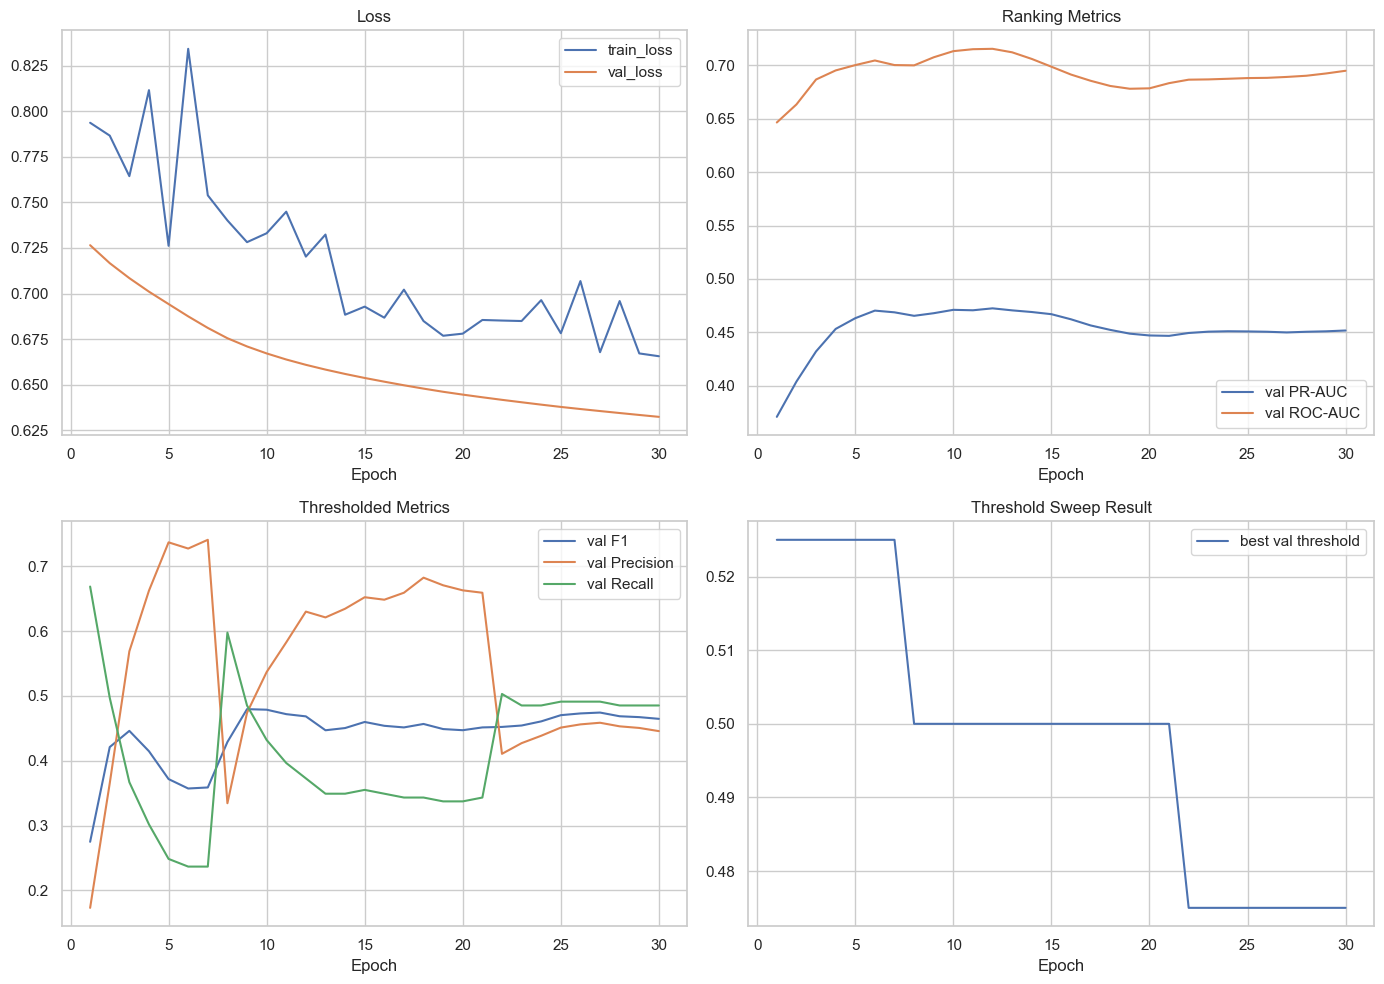

In [32]:
best_model, history_df = train_model(
    model=model,
    data=data,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    epochs=EPOCHS,
    patience=PATIENCE,
    threshold_objective=THRESHOLD_OBJECTIVE,
)

display(history_df.tail())
plot_training_history(history_df)


In [33]:
val_true, val_prob = predict_probabilities(best_model, data, "val_mask")
best_threshold = find_best_threshold(val_true, val_prob, objective=THRESHOLD_OBJECTIVE)

test_true, test_prob = predict_probabilities(best_model, data, "test_mask")
test_metrics = evaluate_probabilities(test_true, test_prob, best_threshold)

metrics_df = pd.DataFrame([test_metrics]).T.rename(columns={0: "value"})
display(metrics_df)


,value
Threshold,0.500000
PR-AUC,0.474833
ROC-AUC,0.685606
F1,0.483986
Precision,0.607143
Recall,0.402367
Specificity,0.966942
NPV,0.927233
Balanced-Accuracy,0.684655
MCC,0.444241


In [34]:
report_df = classification_report_df(test_true, test_prob, best_threshold)
display(report_df)


,precision,recall,f1-score,support
0,0.927233,0.966942,0.946672,1331.000000
1,0.607143,0.402367,0.483986,169.000000
accuracy,0.903333,0.903333,0.903333,0.903333
macro avg,0.767188,0.684655,0.715329,1500.000000
weighted avg,0.891170,0.903333,0.894542,1500.000000


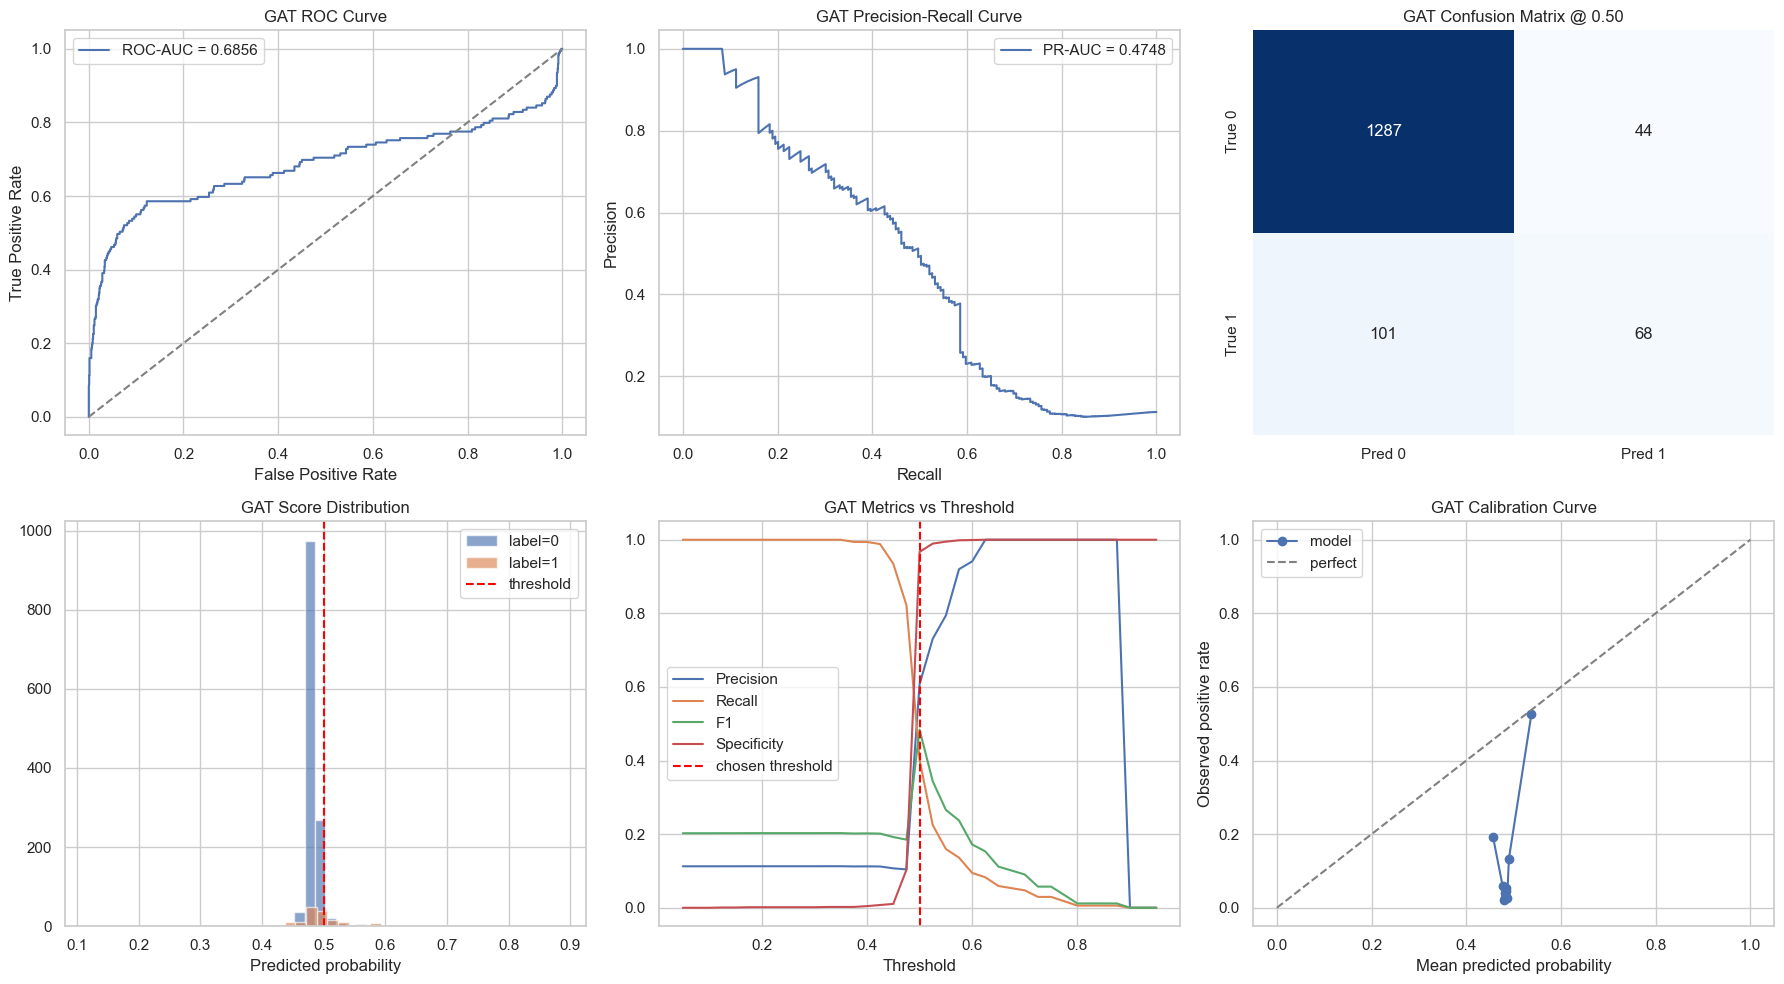

In [35]:
plot_evaluation_dashboard(
    y_true=test_true,
    y_prob=test_prob,
    threshold=best_threshold,
    title_prefix=MODEL_NAME.upper(),
)


In [36]:
test_node_rows = data["nodes_df"].loc[data["test_mask"].detach().cpu().numpy()].copy()
test_node_rows["predicted_probability"] = test_prob
test_node_rows["predicted_label"] = (test_prob >= best_threshold).astype(int)

suspicious_wallets = test_node_rows.sort_values("predicted_probability", ascending=False).head(25)
display(
    suspicious_wallets[
        [
            "node_id",
            "label",
            "predicted_probability",
            "predicted_label",
            "full_total_degree",
            "sub_total_degree",
        ]
    ]
)


,node_id,label,predicted_probability,predicted_label,full_total_degree,sub_total_degree
2046,258361,1,0.887143,1,2,0
1773,230116,1,0.784370,1,1,0
2209,276703,1,0.777584,1,1,0
1539,204115,1,0.771560,1,1,1
1520,203021,1,0.769536,1,1,0
1598,210566,1,0.723702,1,1,0
2492,310231,1,0.713593,1,1,1
1982,253484,1,0.709391,1,1,1
2643,328725,1,0.675225,1,2,1
6045,766063,1,0.660420,1,2,1


## Notes

Keep the reported `PR-AUC`, `Recall`, `Precision`, `F1`, `Balanced-Accuracy`, and `MCC` together when comparing models.
The threshold comes from validation data and is reused on the test split.
